In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz, solve, pinv,inv
from scipy.signal import lfilter, freqz 

# Exercice 4.1 — Approximation de Padé

## Fonction de pade

In [2]:
def pade(x, p, q):
    """
    Padé approximation: model signal x by an ARMA(p, q) filter H(z) = B(z)/A(z)
    whose impulse response matches x exactly over the first p+q+1 samples.

    Inputs
    ------
    x : 1-D array, length N        the signal to model
    p : int                        number of poles   (denominator order)
    q : int                        number of zeros   (numerator order)

    Outputs
    -------
    ap   : 1-D array, length p+1   denominator coeffs [1, a1, ..., ap]
    bq   : 1-D array, length q+1   numerator coeffs   [b0, ..., bq]
    Els  : float                   reconstruction error ||x - xhat||_2
    xhat : 1-D array, length N     reconstructed impulse response

    Key points
    ---------------------
    - xz : x left-padded with p zeros, so a "negative-time" index falls on a 0.
           After padding, old index k is read at position k+p.
    - Step 1 (poles): solve Xq @ a = -xq_1, a square p x p system.
           solve() returns only [a1..ap]; the leading 1 is prepended by hand.
    - Step 2 (zeros): bq = X0 @ ap, a plain matrix-vector product (no solve).
    - p == 0 (pure MA): no poles, ap = [1], step 1 is skipped.
    - delta : unit impulse [1, 0, 0, ...]; feeding it to the filter returns
              the impulse response, i.e. xhat.
    - raises ValueError if Xq is singular (slide cases II/III, not handled).
    """
    xz = np.concatenate([np.zeros(p), x])   # left-pad: negative-time samples = 0

    # --- Step 1: denominator ap (poles) ---
    if p == 0:                              # pure MA: no poles, A(z) = 1
        ap = np.array([1.0])
    else:
        start  = q + p                      # padding offset for row n = q+1
        Xq_col = xz[start     : start + p]      # first column of Xq, p values
        Xq_row = xz[q + 1     : q + p + 1][::-1] # first row of Xq, reversed
        xq_1   = xz[start + 1 : start + 1 + p]   # right-hand side x_{q+1}
        Xq = toeplitz(Xq_col, Xq_row)           # p x p Toeplitz system matrix

        if np.linalg.det(Xq) == 0:
            raise ValueError("Xq is a singular matrix!")

        ap_tail = np.linalg.solve(Xq, -xq_1)    # solves [a1..ap] only
        ap = np.concatenate(([1.0], ap_tail))   # prepend the fixed 1

    # --- Step 2: numerator bq (zeros) ---
    X0_col = x[0 : q + 1]                    # first column of X0, q+1 values
    X0_row = np.zeros(p + 1)                 # first row: [x(0), 0, ..., 0]
    X0_row[0] = x[0]
    X0 = toeplitz(X0_col, X0_row)            # (q+1) x (p+1) Toeplitz matrix
    bq = X0 @ ap                             # b = X0 @ ap  (no system to solve)

    # --- Reconstruction: impulse response of filter bq/ap ---
    delta = np.zeros(len(x))                 # unit impulse [1, 0, 0, ...]
    delta[0] = 1.0
    xhat = lfilter(bq, ap, delta)            # impulse response = reconstruction
    Els  = np.linalg.norm(x - xhat)          # L2 error over all N samples

    return ap, bq, Els, xhat

# Exercice 4.1 — Approximation de Padé

## 4.1.1 Introduction et définition du signal

L'objectif est de tester l'approximation de Padé sur un signal test $x(n)$ défini sur $N = 12$ échantillons :

$$x(0) = 1, \qquad x(n) = 3 \cdot (0.5)^n \quad \text{pour } n = 1, \dots, N-1$$

> **Qu'est-ce que l'approximation de Padé ?**  
> L'approximation de Padé consiste à modéliser un signal $x(n)$ par un filtre rationnel $H(z) = \frac{B(z)}{A(z)}$ de type ARMA$(p, q)$, dont la réponse impulsionnelle coïncide **exactement** avec $x(n)$ sur les $p + q + 1$ premiers échantillons. C'est une méthode déterministe (pas d'estimation statistique) qui cherche les coefficients $a_p$ et $b_q$ tels que le signal soit reproduit sans erreur sur une fenêtre finie.

> **Pourquoi ce signal ?**  
> $x(n) = 3 \cdot (0.5)^n$ est une exponentielle décroissante — signal canonique d'un système pôle unique en $z = 0.5$. L'approximation de Padé devrait donc retrouver exactement ce pôle.

In [3]:
# Paramètres du signal
N = 12
n = np.arange(N)
xn = np.zeros(N)
xn[0] = 1.0
xn[1:] = 3 * (0.5)**n[1:]

print("Signal xn (12 échantillons) :") # faire un table  a  2  colonnes : n et xn
print("n\t\txn")
for i in range(len(n)):
    print(f"{n[i]}\t\t{xn[i]}")

Signal xn (12 échantillons) :
n		xn
0		1.0
1		1.5
2		0.75
3		0.375
4		0.1875
5		0.09375
6		0.046875
7		0.0234375
8		0.01171875
9		0.005859375
10		0.0029296875
11		0.00146484375


## 4.1.2. Test a) — Modèle AR(2) ($p=2, q=0$)

On cherche un modèle purement auto-régressif : le signal est modélisé par un filtre tout-pôle $H(z) = \frac{b_0}{A(z)}$, sans zéros.

La démarche est la suivante :

1. **Construire la matrice de convolution** $X$ à partir de $x(n)$ via la fonction `get_conv_mtx(x, p)` — cette matrice de Toeplitz encode les décalages successifs du signal.

2. **Extraire** la sous-matrice $X_q$ (lignes $q+1$ à $q+p$) et le vecteur $x_{q+1}$ correspondant.

3. **Résoudre** le système linéaire pour trouver les coefficients du dénominateur $\mathbf{a}_p$ :
$$X_q \, \mathbf{a}_p = -\mathbf{x}_{q+1}$$

4. **Calculer** le coefficient $b_0$ (gain) à partir de la première équation.

> **Pour $q=0$ (modèle AR pur) :** il n'y a aucun zéro, donc $B(z) = b_0$ est un simple scalaire. Tout le comportement du signal est capturé par les pôles de $A(z)$. Avec $p=2$, on cherche deux pôles — on s'attend à retrouver $z = 0.5$ comme pôle dominant.

Coefficients ap : [ 1.  -1.5  1.5]
Coefficients bq : [1.]
Erreur Els : 15.7206


<>:12: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:20: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:12: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:20: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/tmp/ipykernel_23202/878788075.py:12: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.stem(n, xhat, linefmt='r-', markerfmt='ro', label='Signal reconstruit $\hat{x}(n)$')
/tmp/ipykernel_23202/878788075.py:20: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will

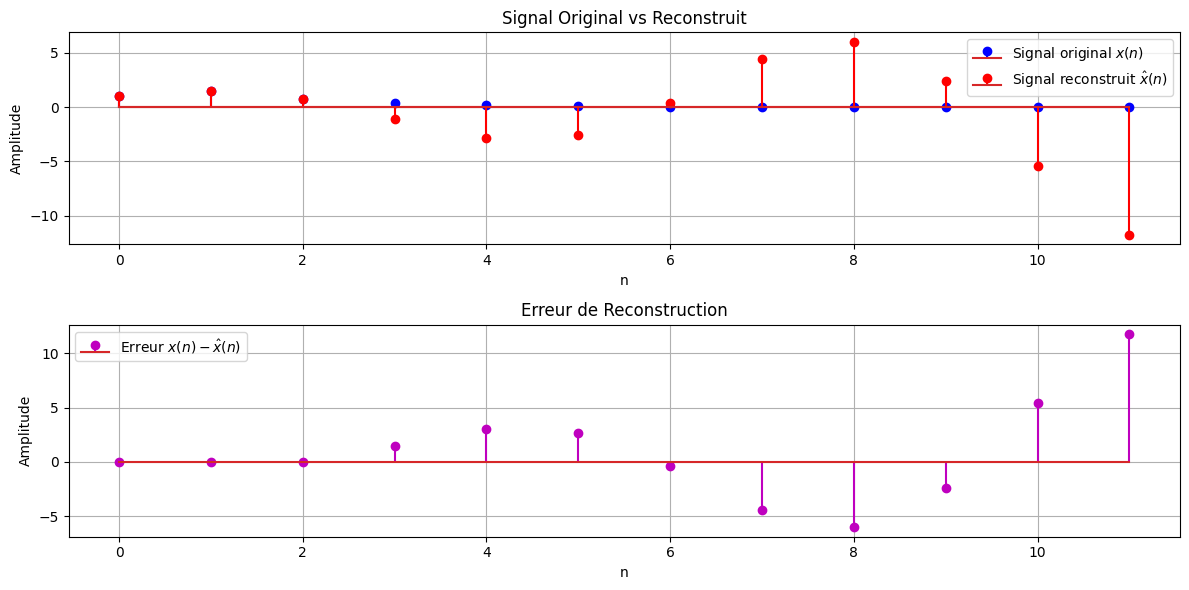

In [4]:
ap, bq, Els, xhat = pade(xn, p=2, q=0)

print(f"Coefficients ap : {ap}")
print(f"Coefficients bq : {bq}")
print(f"Erreur Els : {Els:.4f}")

# Visualisation
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.stem(n, xn,   linefmt='b-', markerfmt='bo', label='Signal original $x(n)$')
plt.stem(n, xhat, linefmt='r-', markerfmt='ro', label='Signal reconstruit $\hat{x}(n)$')
plt.title("Signal Original vs Reconstruit")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.stem(n, xn - xhat, linefmt='m-', markerfmt='mo', label='Erreur $x(n) - \hat{x}(n)$')
plt.title("Erreur de Reconstruction")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## 4.1.3. Test b) — Modèle MA(2) ($p=0, q=2$)

Pour un modèle purement Moving Average (filtre FIR), la solution est **triviale** : la réponse impulsionnelle d'un filtre MA est exactement ses coefficients $b_q$. Donc :

$$b_q = [x(0),\ x(1),\ x(2)], \qquad a_p = [1]$$

> **Pourquoi c'est trivial ?**  
> Un filtre MA d'ordre $q$ a une réponse impulsionnelle de longueur finie $q+1$. Par définition de Padé, on impose que $h(n) = x(n)$ sur les premiers échantillons — pour un modèle tout-zéro, cela revient simplement à lire les $q+1$ premières valeurs du signal.

> **Limite du modèle MA ici :** Le signal $x(n) = 3 \cdot (0.5)^n$ est une exponentielle infinie. Un modèle MA(2) ne peut reproduire que les 3 premiers échantillons exactement — l'erreur sera non nulle à partir de $n = 3$, contrairement au modèle AR qui capture la décroissance exponentielle avec seulement un pôle.

Coefficients ap : [1.]
Coefficients bq : [1.   1.5  0.75]
Erreur Els : 0.4330


<>:12: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:20: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:12: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:20: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/tmp/ipykernel_23202/3110637179.py:12: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.stem(n, xhat, linefmt='r-', markerfmt='ro', label='Signal reconstruit $\hat{x}(n)$')
/tmp/ipykernel_23202/3110637179.py:20: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences wi

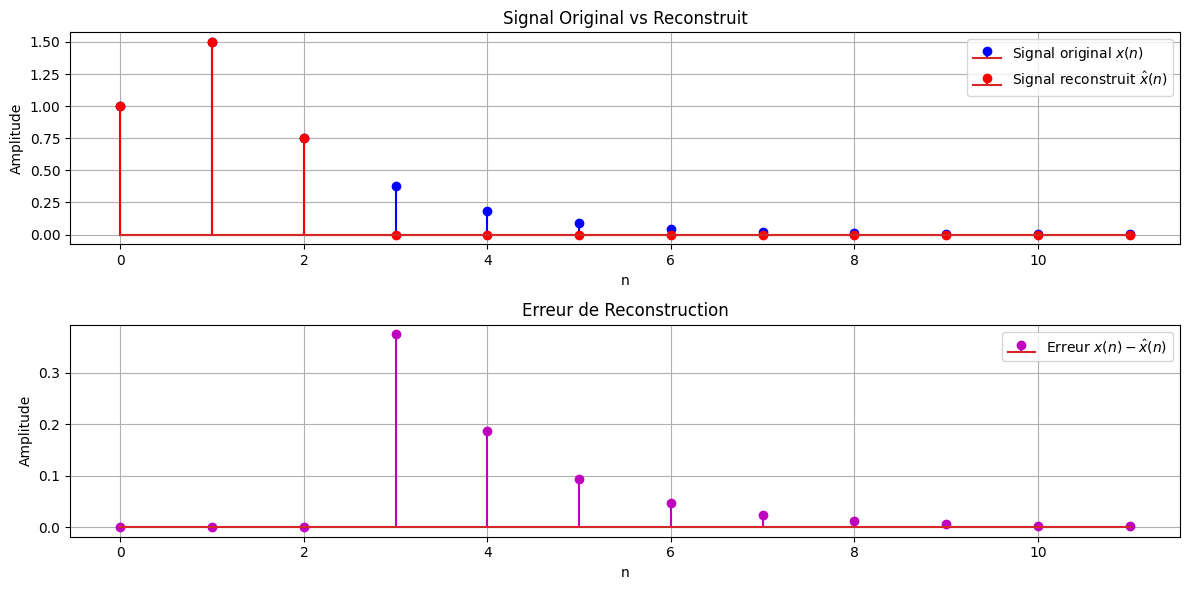

In [5]:
ap, bq, Els, xhat = pade(xn, p=0, q=2)

print(f"Coefficients ap : {ap}")
print(f"Coefficients bq : {bq}")
print(f"Erreur Els : {Els:.4f}")

# Visualisation
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.stem(n, xn,   linefmt='b-', markerfmt='bo', label='Signal original $x(n)$')
plt.stem(n, xhat, linefmt='r-', markerfmt='ro', label='Signal reconstruit $\hat{x}(n)$')
plt.title("Signal Original vs Reconstruit")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.stem(n, xn - xhat, linefmt='m-', markerfmt='mo', label='Erreur $x(n) - \hat{x}(n)$')
plt.title("Erreur de Reconstruction")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## 4.1.4. Test c) — Modèle ARMA(1,1) ($p=1, q=1$)

On cherche un modèle mixte $H(z) = \frac{B(z)}{A(z)}$ avec un pôle et un zéro. La résolution se fait en deux étapes :

**Étape 1 — Calcul de $a_p$ (dénominateur) :**  
On utilise les équations de Padé décalées, c'est-à-dire les lignes de la matrice de convolution à partir de l'indice $q+1$ :
$$X_q \, \mathbf{a}_p = -\mathbf{x}_{q+1}$$
Ces équations ne font intervenir que les pôles, car pour $n > q$ la contribution des zéros a disparu.

**Étape 2 — Calcul de $b_q$ (numérateur) :**  
Une fois $a_p$ connu, les coefficients du numérateur sont obtenus directement par :
$$\mathbf{b}_q = X_{0:q+1} \cdot \mathbf{a}_p$$
où $X_{0:q+1}$ est la sous-matrice des $q+1$ premières lignes de la matrice de convolution.

> **Avantage du modèle ARMA(1,1) ici :** Avec seulement $p+q+1 = 3$ paramètres (comme le MA(2)), le modèle ARMA capture à la fois la décroissance exponentielle (via le pôle) et un ajustement fin des premiers échantillons (via le zéro) — on s'attend à une erreur bien plus faible que le MA(2).

Coefficients ap : [ 1.  -0.5]
Coefficients bq : [1. 1.]
Erreur Els : 0.0000


<>:12: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:20: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:12: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:20: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/tmp/ipykernel_23202/2842837235.py:12: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.stem(n, xhat, linefmt='r-', markerfmt='ro', label='Signal reconstruit $\hat{x}(n)$')
/tmp/ipykernel_23202/2842837235.py:20: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences wi

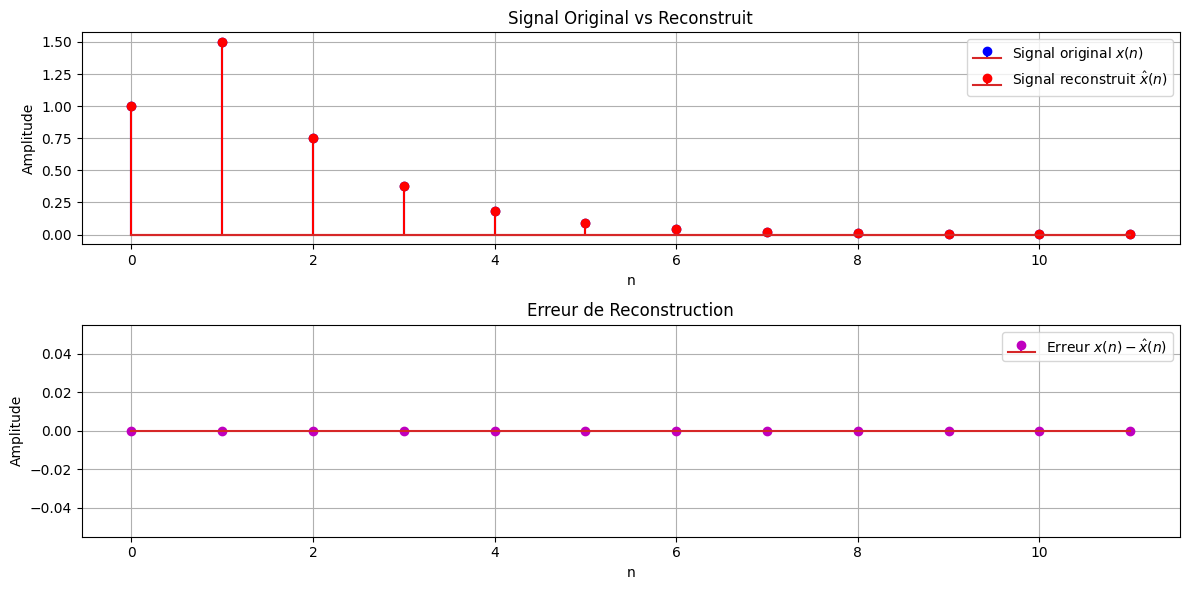

In [6]:
ap, bq, Els, xhat = pade(xn, p=1, q=1)

print(f"Coefficients ap : {ap}")
print(f"Coefficients bq : {bq}")
print(f"Erreur Els : {Els:.4f}")

# Visualisation
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.stem(n, xn,   linefmt='b-', markerfmt='bo', label='Signal original $x(n)$')
plt.stem(n, xhat, linefmt='r-', markerfmt='ro', label='Signal reconstruit $\hat{x}(n)$')
plt.title("Signal Original vs Reconstruit")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.stem(n, xn - xhat, linefmt='m-', markerfmt='mo', label='Erreur $x(n) - \hat{x}(n)$')
plt.title("Erreur de Reconstruction")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## 4.1.5. Fonction Générale `pade(x, p, q)`

Écrire une fonction qui automatise le calcul des coefficients de Padé pour n'importe quel ordre $(p, q)$.

La fonction doit implémenter les trois étapes générales :

1. **Calcul de $a_p$** (si $p > 0$) : construire la matrice de convolution complète, extraire $X_q$ (lignes $q+1$ à $q+p$, colonnes $0$ à $p$) et résoudre $X_q \, \mathbf{a}_p = -\mathbf{x}_{q+1}$. Vérifier que $X_q$ est non singulière avant de résoudre.

2. **Calcul de $b_q$** : extraire les $q+1$ premières lignes de la matrice de convolution et calculer $\mathbf{b}_q = X_{0:q+1} \cdot \mathbf{a}_p$.

3. **Reconstruction et erreur** : calculer $\hat{x}(n) = h(n) = $ réponse impulsionnelle du filtre $H(z) = B(z)/A(z)$, puis l'erreur $E = \|x - \hat{x}\|_2$.

```python
def pade(x, p, q):
    N_sig = len(x)
    if p > 0:
        # 1. Résoudre pour ap
        ...
        # Vérification de singularité
        if np.linalg.det(Xq) == 0:
            raise ValueError("Xq est une matrice singulière !")
        ...
    else:
        ap = np.array([1.0])

    # 2. Résoudre pour bq
    ...

    # 3. Reconstruction et erreur
    ...

    return ap, bq, Els, xhat
```

> **Cas limites à gérer :**
> - $p = 0$ : modèle MA pur, $a_p = [1]$ et $b_q = x[0:q+1]$ directement.
> - $q = 0$ : modèle AR pur, $b_q = [x(0)]$ scalaire.
> - Matrice singulière : le système est indéterminé, lever une exception explicite.

## 4.1.6 Exemple : Design de filtre

### 4.1.6.1 Définition du filtre idéal

L'objectif est de synthétiser un filtre rationnel $H(z) = B(z)/A(z)$ qui approche un **filtre passe-bas idéal à phase linéaire** :

$$H(j f) = \begin{cases} e^{-j n_d 2\pi f} & \text{pour } |f| < F_p \\ 0 & \text{pour } F_p < |f| < 0.5 \end{cases}$$

La réponse en fréquence rectangulaire correspond dans le domaine temporel à une fonction **sinc décalée** de $n_d$ échantillons (retard pur pour assurer la causalité) :

$$h(n) = 2F_p \,\text{sinc}(2F_p(n - n_d)) = \frac{\sin\!\left((n - n_d)\pi/2\right)}{(n-n_d)\pi}$$

**Paramètres :**
- $N = 100$ échantillons
- $F_p = 0.25$ (fréquence de coupure normalisée, soit $f_s/4$)
- $n_d = 5$ (retard de groupe en échantillons)
- Modèle d'approximation : **ARMA(6,6)** — 6 pôles et 6 zéros

> **Pourquoi Padé pour le design de filtre ?**  
> On dispose d'une réponse impulsionnelle cible $h(n)$ (le sinc tronqué). L'approximation de Padé cherche un filtre rationnel ARMA dont la réponse impulsionnelle coïncide exactement avec $h(n)$ sur les $p+q+1 = 13$ premiers échantillons. L'avantage sur un filtre FIR direct est qu'un filtre IIR d'ordre faible peut approcher un filtre idéal avec beaucoup moins de coefficients.

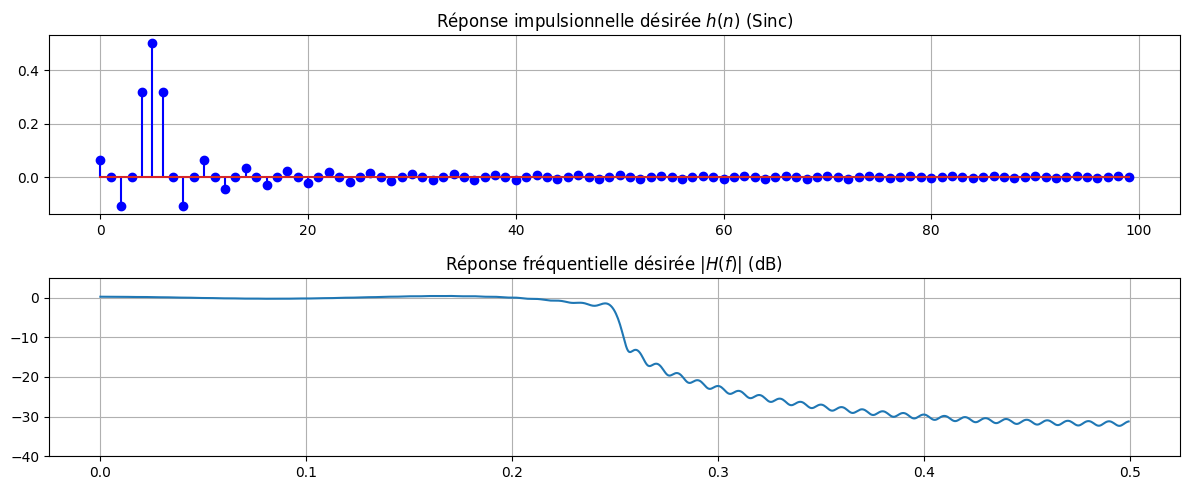

In [7]:
N_filt = 100
Fp = 0.25
nd = 5
n_filt = np.arange(N_filt)
hn = 0.5 * np.sinc((n_filt - nd) * 2 * Fp)

# Visualisation du filtre idéal
plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.stem(n_filt, hn, linefmt='b-', markerfmt='bo')
plt.title("Réponse impulsionnelle désirée $h(n)$ (Sinc)")
plt.grid(True)

plt.subplot(2, 1, 2)
w, H_ideal = freqz(hn, 1, worN=1024)
plt.plot(w/(2*np.pi), 20*np.log10(np.abs(H_ideal)))
plt.title("Réponse fréquentielle désirée $|H(f)|$ (dB)")
plt.ylim([-40, 5])
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.1.6.2 Synthèse avec la fonction Padé — ordre $p=6, q=6$

On applique la fonction `pade(h, p, q)` avec $p = q = 6$ sur la réponse impulsionnelle cible $h(n)$ (sinc tronqué) pour obtenir les coefficients $a_p$ et $b_q$ du filtre rationnel approché.

La réponse impulsionnelle reconstruite $\hat{h}(n)$ doit coïncider exactement avec $h(n)$ sur les $p + q + 1 = 13$ premiers échantillons, puis diverger ou s'éloigner selon la qualité de l'approximation au-delà.

**Ce que l'on visualise :**
- La réponse impulsionnelle cible $h(n)$ (sinc décalé) vs reconstruite $\hat{h}(n)$
- L'erreur de reconstruction $h(n) - \hat{h}(n)$
- La réponse en fréquence $|H(e^{j2\pi f})|$ du filtre synthétisé vs le gabarit idéal rectangulaire

> **Indicateur de qualité :** L'erreur $E = \|h - \hat{h}\|_2$ mesure la qualité globale de l'approximation. Une erreur faible indique que le filtre ARMA(6,6) capture bien le comportement du sinc sur toute la fenêtre de $N$ échantillons.

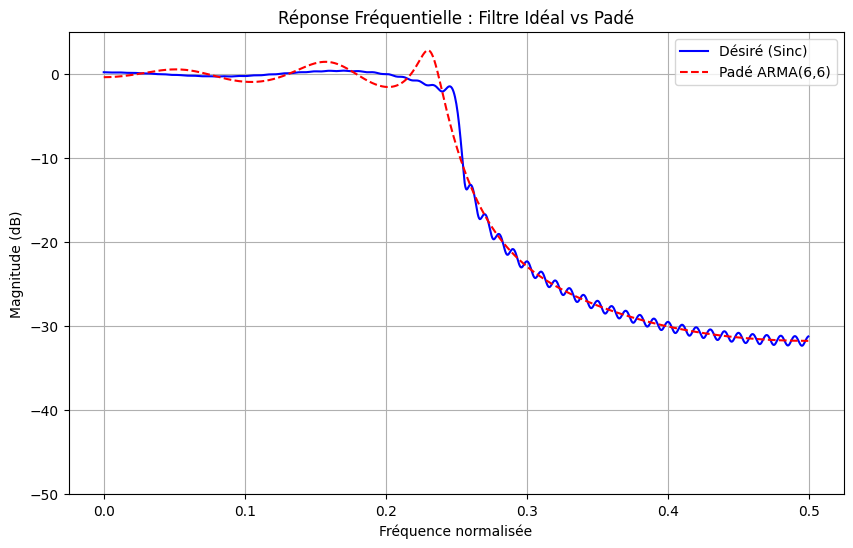

In [8]:
# Approximation Padé ARMA(6,6)
p_iir, q_iir = 6, 6
ap_iir, bq_iir, els_iir, hhat_iir = pade(hn, p_iir, q_iir)

# Affichage fréquentiel
w, H_ideal = freqz(hn, 1, worN=1024)
w, H_pade = freqz(bq_iir, ap_iir, worN=1024)
plt.figure(figsize=(10, 6))
plt.plot(w/(2*np.pi), 20*np.log10(np.abs(H_ideal)), 'b', label='Désiré (Sinc)')
plt.plot(w/(2*np.pi), 20*np.log10(np.abs(H_pade)), 'r--', label='Padé ARMA(6,6)')
plt.title('Réponse Fréquentielle : Filtre Idéal vs Padé')
plt.xlabel('Fréquence normalisée')
plt.ylabel('Magnitude (dB)')
plt.ylim([-50, 5])
plt.legend()
plt.grid(True)
plt.show()